In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv("fixed_final_data.csv", low_memory=False)

In [5]:
df['completed'] = pd.to_datetime(df['completed'], errors='coerce')
df = df.dropna(subset=['completed'])

In [7]:
start_date = pd.Timestamp('2007-01-01')
end_date = pd.Timestamp('2026-2-28')

df = df[(df['completed'] >= start_date) & (df['completed'] <= end_date)]

In [9]:
df = df.set_index('completed')
df = df.sort_index()
ts = df.resample('M').size()
ts = ts.to_frame(name='project_count')

C:\Users\miran\AppData\Local\Temp\ipykernel_35512\4072299970.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.resample('M').size()


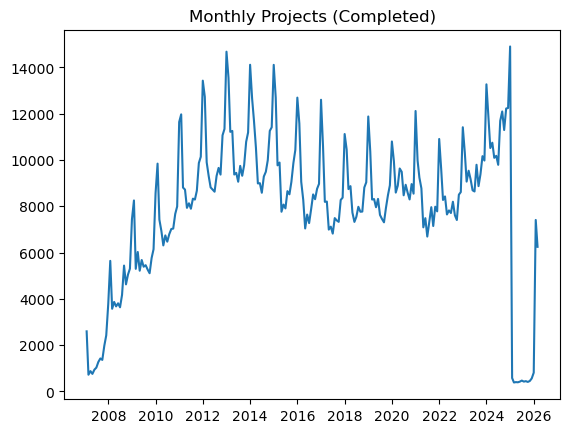

In [11]:
plt.figure()
plt.plot(ts)
plt.title("Monthly Projects (Completed)")
plt.show()

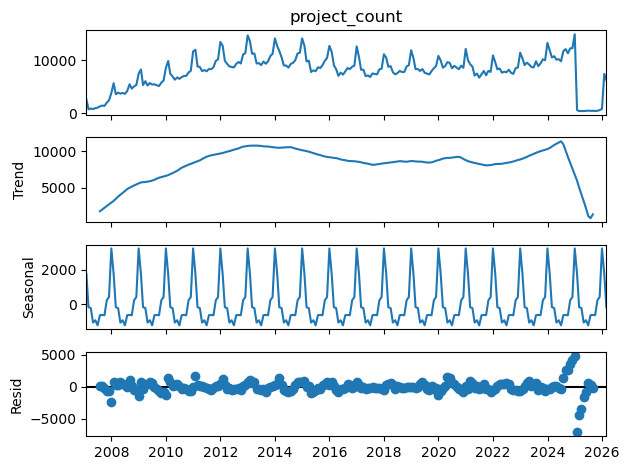

In [13]:
decomposition = seasonal_decompose(ts['project_count'], model='additive', period=12)

decomposition.plot()
plt.show()

In [15]:
model = SARIMAX(
    ts['project_count'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      project_count   No. Observations:                  230
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1724.754
Date:                            Fri, 20 Mar 2026   AIC                           3459.508
Time:                                    12:40:21   BIC                           3476.074
Sample:                                01-31-2007   HQIC                          3466.210
                                     - 02-28-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1545      1.430     -0.108      0.914      -2.957       2.648
ma.L1          0.0291      1.457   

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


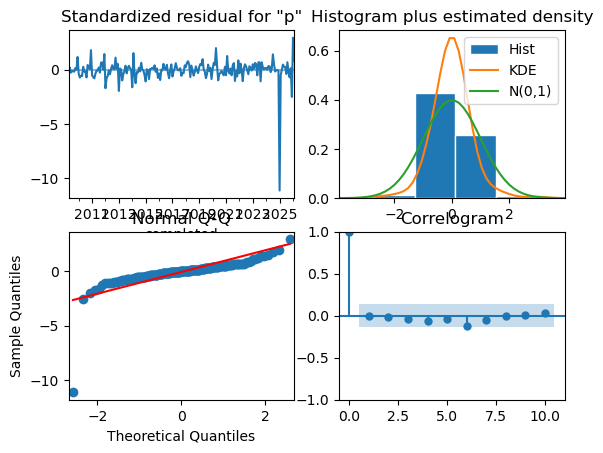

In [17]:
results.plot_diagnostics()
plt.show()

In [19]:
forecast_steps = 12

forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

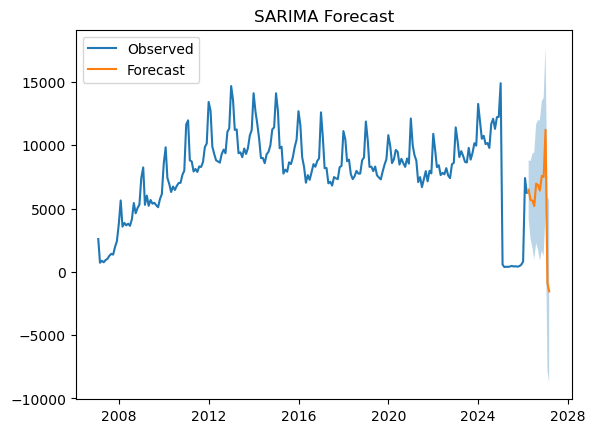

In [21]:
plt.figure()
plt.plot(ts, label='Observed')
plt.plot(forecast_mean, label='Forecast')

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.legend()
plt.title("SARIMA Forecast")
plt.show()